2026-04-16 19:44:23.227927: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-04-16 19:44:23.251141: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1776339863.288114   19345 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1776339863.299595   19345 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-04-16 19:44:23.329375: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instr


Processing Grad-CAM for CarRacing_SPDA...


/home/ustc15/anaconda3/envs/nac/lib/python3.10/site-packages/keras/src/saving/saving_lib.py:757: UserWarning: Skipping variable loading for optimizer 'adamw', because it has 2 variables whereas the saved optimizer has 58 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))



Processing Grad-CAM for CarRacing_ODEFormer...

Processing Grad-CAM for CarRacing_ContiFormer...


/home/ustc15/anaconda3/envs/nac/lib/python3.10/site-packages/keras/src/saving/saving_lib.py:757: UserWarning: Skipping variable loading for optimizer 'adamw', because it has 2 variables whereas the saved optimizer has 68 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))



Processing Grad-CAM for CarRacing_OTTransformer...


/home/ustc15/anaconda3/envs/nac/lib/python3.10/site-packages/keras/src/ops/nn.py:907: UserWarning: You are using a softmax over axis 3 of a tensor of shape (1, 16, 1, 1). This axis has size 1. The softmax operation will always return the value 1, which is likely not what you intended. Did you mean to use a sigmoid instead?
  warnings.warn(



Processing Grad-CAM for CarRacing_FLUID...


/home/ustc15/anaconda3/envs/nac/lib/python3.10/site-packages/keras/src/saving/saving_lib.py:757: UserWarning: Skipping variable loading for optimizer 'adamw', because it has 2 variables whereas the saved optimizer has 232 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))
2026-04-16 19:44:39.399686: E tensorflow/core/util/util.cc:131] oneDNN supports DT_INT32 only on platforms with AVX-512. Falling back to the default Eigen-based implementation if present.


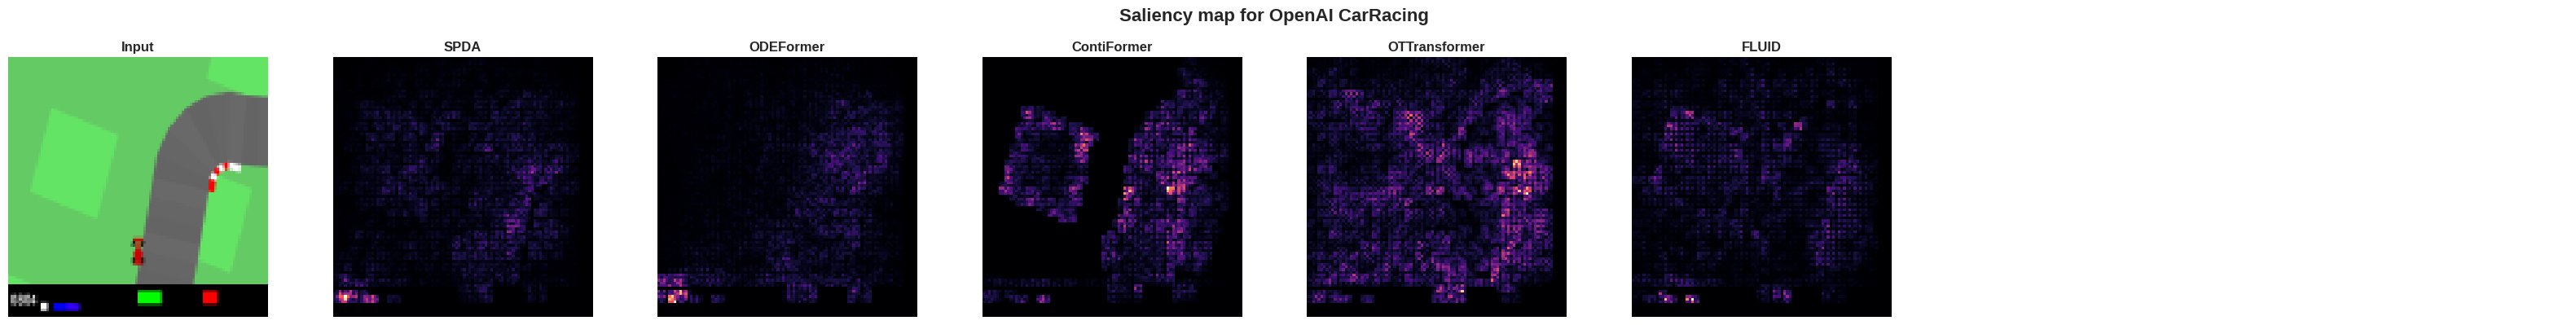

In [1]:
import os
os.environ["CUDA_VISIBLE_DEVICES"] = "-1"

import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Model
import matplotlib.pyplot as plt
from baseline_cells import ODEformer, ContiFormer, SPDATransformer,OTTransformer
from tensorflow.keras.optimizers import AdamW
import pickle
import math
import matplotlib.pyplot as plt
from FLUID import FLUID


base_model_name = 'CarRacing'
weights_dir = 'model_weights2'
plot_dir = 'plots'


X = []
y = []
pickle_in = open('CarRacing/data/data.pickle','rb')
data = pickle.load(pickle_in)

for obs,actions in data:
    X.append(obs)
    y.append(actions)

X_events = np.expand_dims(np.array(X),axis=1)
y = np.array(y).astype(dtype='uint8')

num_classes = len(np.unique(y))


# ---- Model builder ----
def build_model(name, input_shape=(None, 96, 96, 3)):
    inp = tf.keras.Input(shape=input_shape)

    x = tf.keras.layers.TimeDistributed(tf.keras.layers.Conv2D(10, (3, 3), activation='relu', strides=2))(inp)
    x = tf.keras.layers.TimeDistributed(tf.keras.layers.Dropout(0.2))(x)
    x = tf.keras.layers.TimeDistributed(tf.keras.layers.Conv2D(20, (5, 5), activation='relu', strides=2))(x)
    x = tf.keras.layers.TimeDistributed(tf.keras.layers.Dropout(0.2))(x)
    x = tf.keras.layers.TimeDistributed(tf.keras.layers.Conv2D(30, (5, 5), activation='relu', strides=2))(x)
    x = tf.keras.layers.TimeDistributed(tf.keras.layers.Dropout(0.2))(x)
    x = tf.keras.layers.TimeDistributed(tf.keras.layers.Flatten())(x)

    if name == "FLUID":
        x = FLUID(d_model=64, num_heads=16, ff_dim=64, topk=10, max_len=5000)(x)
    elif name == "ContiFormer":
        x = tf.keras.layers.Dense(64)(x)
        x = ContiFormer(dim=64, num_heads=16, ff_dim=64)(x)
    elif name == "ODEFormer":
        x = ODEformer(hidden_dim=64, num_heads=16, ff_dim=64)(x)
    elif name == "OTTransformer":
        x = OTTransformer(key_dim=64, num_heads=16, ff_dim=64)(x)
    elif name == "SPDA":
        x = SPDATransformer(embed_dim=64, num_heads=16, ff_dim=64)(x)
    else:
        raise ValueError(f"Unknown model name: {name}")

    x = tf.keras.layers.GlobalMaxPooling1D()(x)
    x = tf.keras.layers.Dense(64, activation='relu')(x)
    out = tf.keras.layers.Dense(5, activation='softmax')(x)
    return tf.keras.Model(inp, out)

# ---- Model types ----
model_types = ["SPDA", "ODEFormer", "ContiFormer", "OTTransformer", "FLUID"]
model_names = ["SPDA", "ODEFormer", "ContiFormer", "OTTransformer", "FLUID"]

# Pick a single sample
sample_idx = 15000
target_class = np.argmax(y[sample_idx])

# Original image
original_image = X_events[sample_idx]  # shape (96, 96, 3)

# Prepare input for model
frame_input = tf.convert_to_tensor(X_events[sample_idx:sample_idx+1], dtype=tf.float32)

gradcams = []

for cell_type in model_types:
    model_name = f"{base_model_name}_{cell_type}"
    print(f"\nProcessing Grad-CAM for {model_name}...")

    # Build and load model
    model = build_model(cell_type, input_shape=(None,96, 96, 3))
    model.compile(optimizer=AdamW(learning_rate=0.0001),loss="sparse_categorical_crossentropy",metrics=["accuracy"])
    model.load_weights(f"{weights_dir}/{model_name}.keras")

    # Compute Grad-CAM / saliency
    with tf.GradientTape() as tape:
        tape.watch(frame_input)
        output = model(frame_input)
        loss = output[:, target_class]

    grads = tape.gradient(loss, frame_input)
    saliency = tf.reduce_max(tf.abs(grads[0]), axis=-1)
    saliency /= tf.reduce_max(saliency) + 1e-8  # normalize
    saliency = saliency.numpy().squeeze()  # remove batch dim

    gradcams.append(saliency)



plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams.update({
    "font.size": 8,
    "axes.titlesize": 10,
    "axes.labelsize": 9,
    "legend.fontsize": 9,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "lines.linewidth": 1.2,
    "lines.markersize": 3,
})

# Total images: original + Grad-CAMs
num_images = 1 + len(gradcams)
cols = 8
rows = math.ceil(num_images / cols)

fig, axes = plt.subplots(rows, cols, figsize=(4*cols, 4*rows))
#super title of figure
fig.suptitle("Saliency map for OpenAI CarRacing\n", fontsize=16, fontweight='bold')
axes = axes.flatten()  # flatten so we can index easily

# Original image
axes[0].imshow(original_image.squeeze())
axes[0].set_title("Input",fontweight='bold',fontsize=12)
axes[0].axis('off')

# Grad-CAM images
for i, saliency in enumerate(gradcams):
    axes[i + 1].imshow(original_image.squeeze(),alpha=0.55)
    axes[i + 1].imshow(saliency, cmap='magma', alpha=1.0)
    axes[i + 1].set_title(model_names[i],fontweight='bold',fontsize=12)
    axes[i + 1].axis('off')

# Hide any unused subplots
for j in range(num_images, len(axes)):
    axes[j].axis('off')

plt.tight_layout()
plt.savefig(f'{plot_dir}/OpenAI salienymap.jpg', dpi=300)
plt.show()
